In [1]:
# Лабораторная работа №11 Горьков Антон 5130901/30201
# Глава 11. Модуляция и выборка (квантование)

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.io import wavfile
from thinkdsp import Wave, decorate

In [ ]:
# Упражнение 11.3
#
# Если брать выборки из сигнала при слишком низкой частоте кадров,
# компоненты выше частоты заворота дадут биения.
# После этого их уже нельзя отфильтровать, потому что они неотличимы
# от более низких частот.
#
# Поэтому перед выборкой используют фильтр НЧ,
# который называется фильтром сглаживания.
#
# Нужно вернуться к примеру «Соло на барабане»,
# применить фильтр НЧ до выборки, а затем еще раз применить
# фильтр НЧ после выборки, чтобы удалить спектральные копии.
# Результат должен совпадать с предварительно отфильтрованным сигналом.

In [5]:
framerate, ys = wavfile.read('263868__kevcio__amen-break-a-160-bpm.wav')
print(framerate, ys.shape, ys.dtype)

44100 (264600, 2) int16


/var/folders/wd/tn0z_gl176xb8mkdb0t85gt00000gn/T/ipykernel_6791/924738889.py:1: WavFileWarning: Chunk (non-data) not understood, skipping it.
  framerate, ys = wavfile.read('263868__kevcio__amen-break-a-160-bpm.wav')


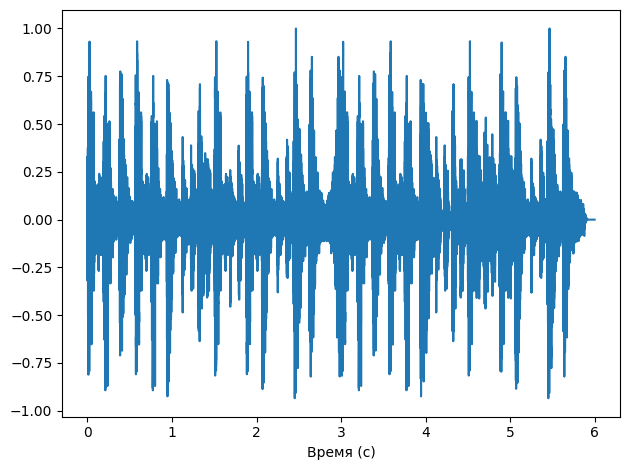

In [7]:
if ys.ndim == 2:
    ys = ys.mean(axis=1)

ys = ys.astype(float)
ys /= np.max(np.abs(ys))

wave = Wave(ys, framerate=framerate)
wave.plot()
decorate(xlabel='Время (с)')

In [8]:
# Послушаем исходный сигнал.

wave.make_audio()

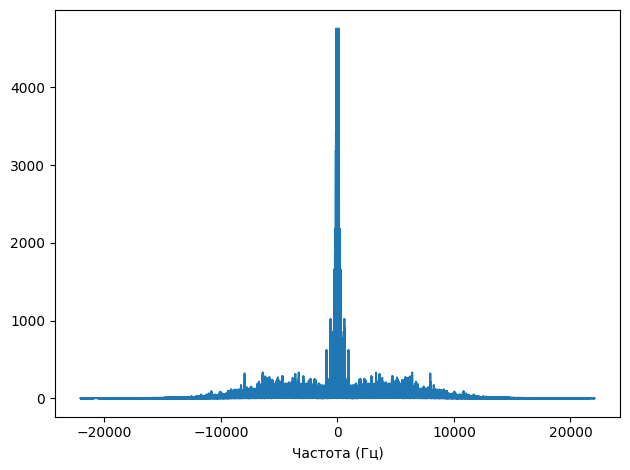

In [9]:
# Вычислим спектр исходного сигнала.

spectrum = wave.make_spectrum(full=True)
spectrum.plot()
decorate(xlabel='Частота (Гц)')

In [10]:
# Уменьшим частоту дискретизации в 3 раза.
# Можно менять factor и смотреть, как меняется результат.

factor = 3
new_framerate = wave.framerate / factor
cutoff = new_framerate / 2 - 1

print(new_framerate, cutoff)

14700.0 7349.0


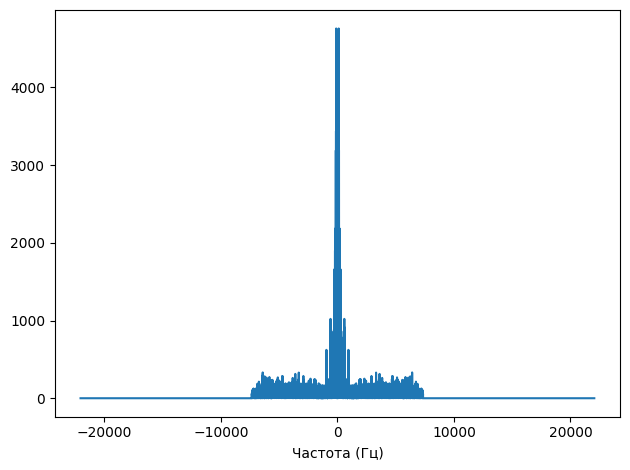

In [11]:
# Сначала применим фильтр сглаживания:
# удалим все частоты выше новой частоты заворота.

filtered_spectrum = spectrum.copy()
filtered_spectrum.low_pass(cutoff)
filtered_spectrum.plot()
decorate(xlabel='Частота (Гц)')

In [12]:
# Преобразуем обратно в сигнал.
# Это сигнал после предварительной фильтрации, но еще до выборки.

filtered = filtered_spectrum.make_wave()
filtered.make_audio()

In [13]:
# Эта функция моделирует процесс выборки:
# оставляет каждый factor-й отсчет, а остальные заменяет нулями.

def sample(wave, factor):
    ys = np.zeros(len(wave))
    ys[::factor] = np.real(wave.ys[::factor])
    return Wave(ys, framerate=wave.framerate)

In [14]:
# Выполним выборку после предварительной фильтрации.

sampled = sample(filtered, factor)
sampled.make_audio()

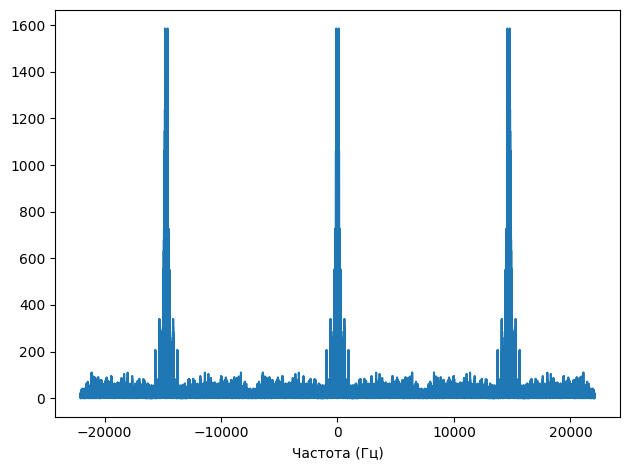

In [15]:
# Посмотрим на спектр после выборки.
# Должны появиться спектральные копии.

sampled_spectrum = sampled.make_spectrum(full=True)
sampled_spectrum.plot()
decorate(xlabel='Частота (Гц)')

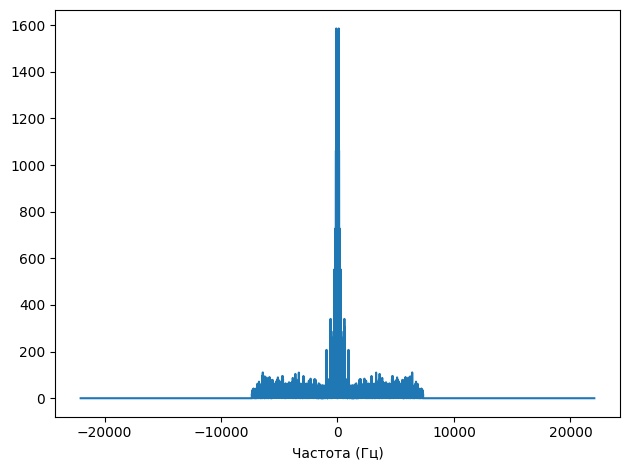

In [16]:
# Теперь снова применим тот же фильтр НЧ,
# чтобы убрать спектральные копии после выборки.

sampled_spectrum.low_pass(cutoff)
sampled_spectrum.plot()
decorate(xlabel='Частота (Гц)')

In [17]:
# После такой операции энергия сигнала уменьшается,
# поэтому масштабируем спектр обратно.

sampled_spectrum.scale(factor)

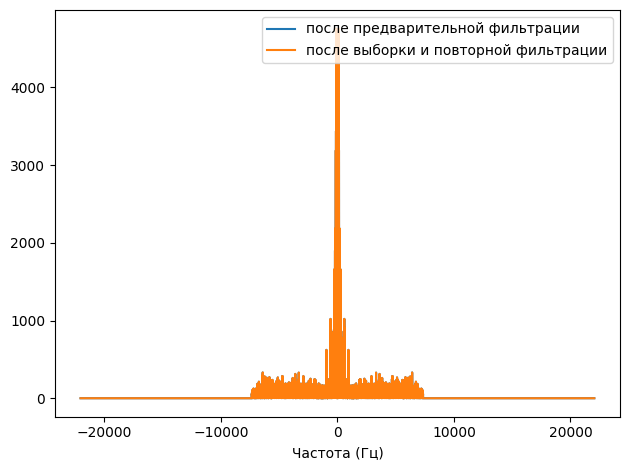

In [18]:
# Сравним спектр до выборки и после повторной фильтрации.

filtered_spectrum.plot(label='после предварительной фильтрации')
sampled_spectrum.plot(label='после выборки и повторной фильтрации')
decorate(xlabel='Частота (Гц)')
plt.legend()

In [19]:
# Разница между спектрами должна быть маленькой.

filtered_spectrum.max_diff(sampled_spectrum)

np.float64(1.016845989170083e-12)

In [20]:
# Преобразуем обратно в сигнал.

interpolated = sampled_spectrum.make_wave()
interpolated.make_audio()

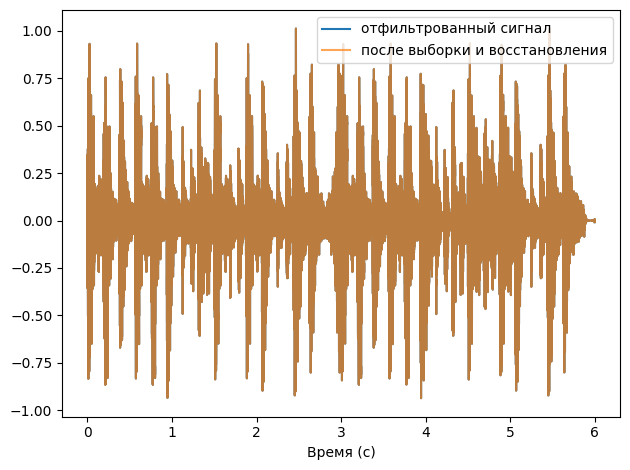

In [21]:
# Сравним сигналы после предварительной фильтрации
# и после всей цепочки "выборка + повторный фильтр".

filtered.plot(label='отфильтрованный сигнал')
interpolated.plot(label='после выборки и восстановления', alpha=0.7)
decorate(xlabel='Время (с)')
plt.legend()

In [22]:
# И численно сравним их.

filtered.max_diff(interpolated)

np.float64(6.661436637913938e-16)

In [ ]:
# Выводы:
# 1. Если убрать высокие частоты до выборки, заворота спектра не возникает.
# 2. После выборки появляются спектральные копии, но не биения,
#    потому что опасные высокие частоты уже удалены.
# 3. Повторный фильтр НЧ удаляет эти спектральные копии.
# 4. После масштабирования восстановленный сигнал получается
#    почти таким же, как предварительно отфильтрованный.
# 5. Значит, фильтр сглаживания перед выборкой действительно
#    предотвращает алиасинг.